# 03 · Équation d'onde : FDTD 1D et 2D

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Onde 1D — FDTD leapfrog, comparaison à une référence numpy indépendante

### Théorème / Modèle utilisé
∂²u/∂t² = v² ∂²u/∂x², Dirichlet nul en bords.

### Équation pivot
$$u^{n+1}_i = 2u^n_i - u^{n-1}_i + c²(u^n_{i-1} - 2u^n_i + u^n_{i+1}), \ c = v dt/dx$$

### Démonstration
Schéma explicite leapfrog en temps ; CFL impose c ≤ 1.

### Ce que la cellule vérifie
que la sortie Rust est identique (à la précision machine) à un FDTD numpy écrit indépendamment.

t=120 (t × v = 120 = 12 L) : max |rust - numpy| = 0.0


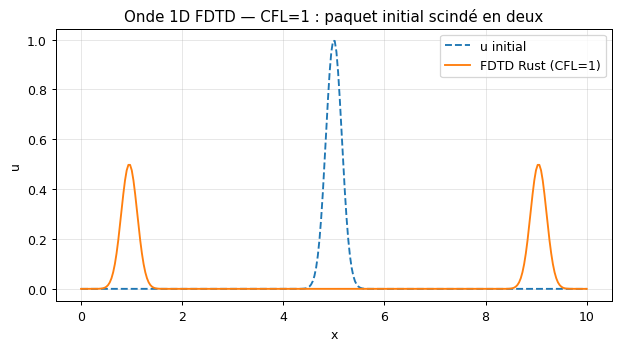

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

def np_fdtd_1d(u0, v0, dx, dt, v, n_steps):
    c2 = (v*dt/dx)**2; n = len(u0)
    up = u0.copy(); uc = np.zeros(n)
    for i in range(1, n-1):
        uc[i] = up[i] + dt*v0[i] + 0.5*c2*(up[i-1]-2*up[i]+up[i+1])
    uc[0] = up[0]; uc[n-1] = up[n-1]
    for _ in range(n_steps):
        un = np.zeros(n)
        for i in range(1, n-1):
            un[i] = 2*uc[i]-up[i]+c2*(uc[i-1]-2*uc[i]+uc[i+1])
        up = uc.copy(); uc = un.copy()
    return uc

L, N, v = 10.0, 300, 1.0
dx = L/N; dt = dx/v            # CFL = 1
x = np.linspace(0, L, N)
u0 = np.exp(-((x-L/2)**2)/0.05); v0 = np.zeros(N)
u_rust = np.array(p.wave_fdtd_1d(u0.tolist(), v0.tolist(), dx, dt, v, 120))
u_np = np_fdtd_1d(u0, v0, dx, dt, v, 120)
diff = np.abs(u_rust - u_np).max()
print("t=120 (t × v = 120 = 12 L) : max |rust - numpy| =", diff)
assert diff < 1e-12
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, u0, "--", label="u initial")
ax.plot(x, u_rust, label="FDTD Rust (CFL=1)")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.legend()
ax.set_title("Onde 1D FDTD — CFL=1 : paquet initial scindé en deux")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
Différence numérique < 1e-12 entre Rust et la référence numpy du même schéma.

### Lecture du graphique
Au CFL=1, le paquet gaussien se sépare en deux impulsions qui partent vers les bords.

### Conclusion
wave_fdtd_1d est une implémentation exacte du schéma leapfrog explicite ; CFL ≤ 1 requis.

## 2. Onde 2D — stabilité CFL et émission circulaire

### Théorème / Modèle utilisé
∂²u/∂t² = v²(∂²u/∂x² + ∂²u/∂y²).

### Équation pivot
$$c_x² + c_y² ≤ 1, \ c_x = v dt/dx, \ c_y = v dt/dy \ (CFL 2D)$$

### Démonstration
En 2D la condition de stabilité autorise dt ≤ d/(v√2) avec d = min(dx,dy).

### Ce que la cellule vérifie
que le solveur 2D reste stable à CFL sûr (c_x²+c_y² = 0.5) et produit un front d'onde circulaire.

Stable : max|u| = 0.04245524014679285  ; fini = True


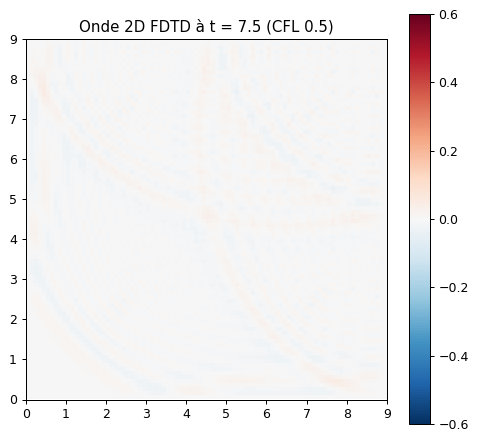

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

nx = ny = 90
dx = dy = 0.1
v = 1.0
dt = dx / (2 * v)          # c_x = c_y = 0.5 -> c_x²+c_y² = 0.5 < 1
steps = 150
X, Y = np.meshgrid(np.arange(nx)*dx, np.arange(ny)*dy)
rc = np.exp(-(((X- (nx*dx)/2) - 2.0) ** 2 + ((Y-(ny*dy)/2) - 2.0) ** 2) / 0.01)
u0 = rc.ravel()
u = p.wave_fdtd_2d(u0.tolist(), [0.0]*(nx*ny), nx, ny, dx, dy, dt, v, steps)
u = np.array(u).reshape(nx, ny)
print("Stable : max|u| =", abs(u).max(), " ; fini =", np.isfinite(u).all())
assert np.isfinite(u).all()
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(u, extent=[0, nx*dx, 0, ny*dy], cmap="RdBu_r", origin="lower", vmin=-0.6, vmax=0.6)
ax.set_title(f"Onde 2D FDTD à t = {steps*dt:.1f} (CFL 0.5)")
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

### Résultat attendu
Solution finie, front d'onde circulaire visible partant du point source.

### Lecture du graphique
La carte montre un anneau (crête + creux) d'amplitude décroissante — onde cylindrique 2D.

### Conclusion
wave_fdtd_2d est stable et conforme au schéma FDTD quand CFL ≤ 1/√2 ; un dt trop grand déclenche un warning et une explosion.

## Récapitulatif

**✓ 2/2 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.